<a href="https://colab.research.google.com/github/nishthadighe-bit/fashion-mnist-vibe-coding/blob/main/Vibe_Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
ann_model = keras.Sequential([
    keras.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
ann_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7732 - loss: 0.6458 - val_accuracy: 0.8547 - val_loss: 0.3953
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8608 - loss: 0.3816 - val_accuracy: 0.8777 - val_loss: 0.3458
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8768 - loss: 0.3338 - val_accuracy: 0.8738 - val_loss: 0.3449
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8847 - loss: 0.3117 - val_accuracy: 0.8762 - val_loss: 0.3349
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8908 - loss: 0.2942 - val_accuracy: 0.8797 - val_loss: 0.3303


In [ ]:
x_train_cnn = x_train.reshape(-1,28,28,1)
x_test_cnn = x_test.reshape(-1,28,28,1)

In [ ]:
cnn_model = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
cnn_model.fit(
    x_train_cnn, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.7716 - loss: 0.6432 - val_accuracy: 0.8757 - val_loss: 0.3494
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.8828 - loss: 0.3219 - val_accuracy: 0.8948 - val_loss: 0.2940
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9022 - loss: 0.2660 - val_accuracy: 0.9007 - val_loss: 0.2634
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.9154 - loss: 0.2309 - val_accuracy: 0.9093 - val_loss: 0.2463
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9232 - loss: 0.2076 - val_accuracy: 0.9092 - val_loss: 0.2472


In [ ]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test)
print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9065 - loss: 0.2639
CNN Test Accuracy: 0.9093000292778015


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


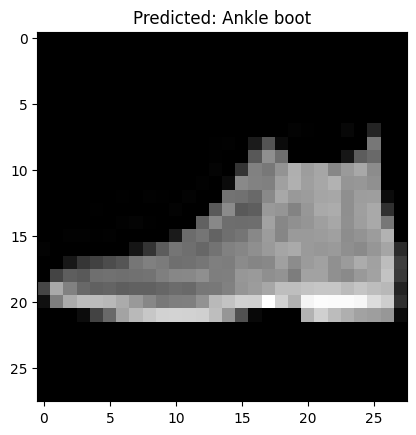

In [ ]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

predictions = cnn_model.predict(x_test_cnn)

plt.imshow(x_test[0], cmap='gray')
plt.title("Predicted: " + class_names[np.argmax(predictions[0])])
plt.show()

In [ ]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


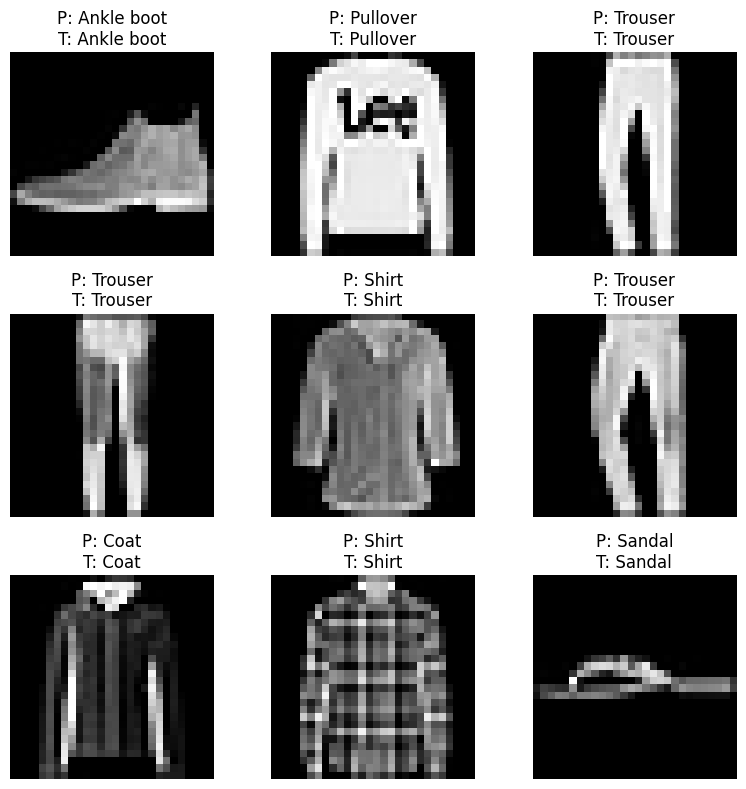

In [ ]:


# Predict
predictions = cnn_model.predict(x_test_cnn)

# Create figure
plt.figure(figsize=(8,8))

for i in range(9):  # show 9 images
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i], cmap='gray')
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]

    plt.title(f"P: {class_names[predicted_label]}\nT: {class_names[true_label]}")
    plt.axis('off')

plt.tight_layout()
plt.show()